## 1. import statements

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [73]:
cars_data=pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 2. Data Understanding

In [4]:
cars_data.shape

(81, 5)

In [5]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [7]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

## Linearity Test

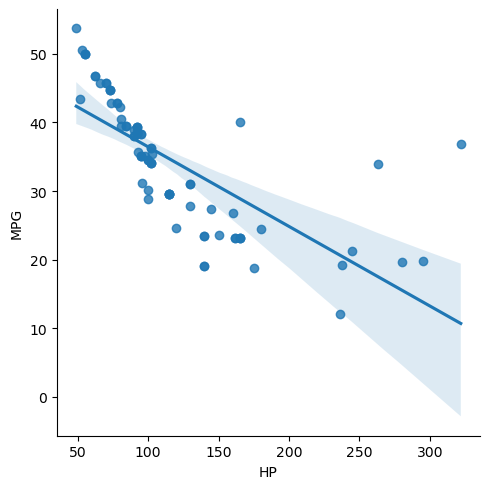

In [15]:
sns.lmplot(cars_data,x="HP",y="MPG")
plt.show()

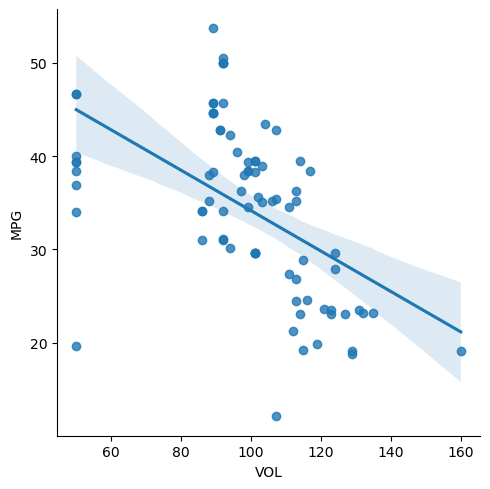

In [16]:
sns.lmplot(cars_data,x="VOL",y="MPG")


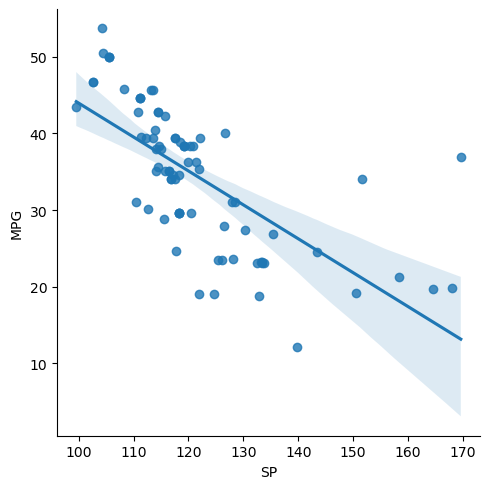

In [17]:
sns.lmplot(cars_data,x="SP",y="MPG")


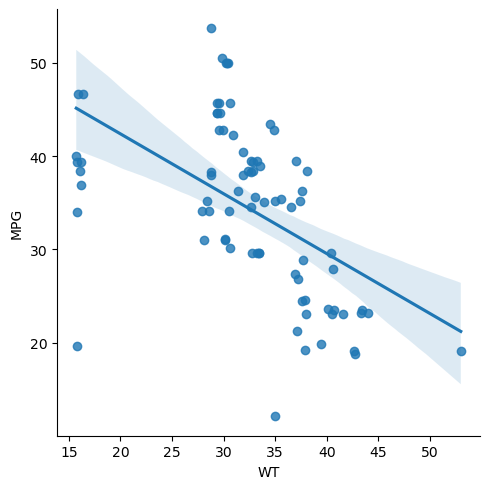

In [18]:
sns.lmplot(cars_data,x="WT",y="MPG")


### Result Linear Test Failed

## Normality Test

C:\Users\a\AppData\Local\Temp\ipykernel_17084\20621330.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=cars_data["HP"])


<Axes: ylabel='Density'>

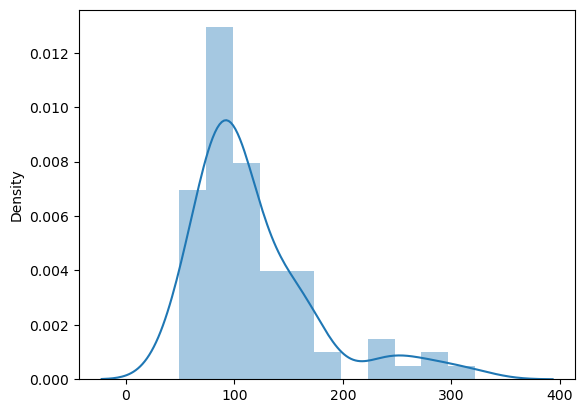

In [25]:
sns.distplot(x=cars_data["HP"])

## Normality Test failed

## 3.correlation Test

In [27]:
corr_matrix=cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

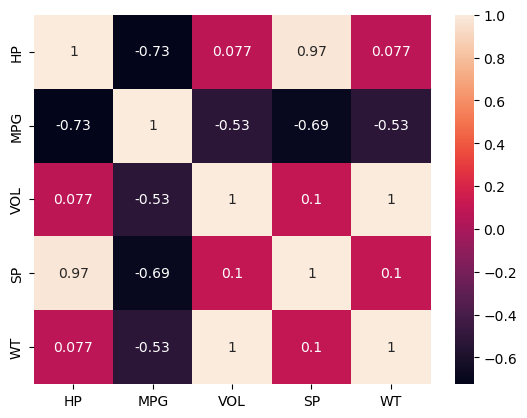

In [30]:
sns.heatmap(data=corr_matrix,annot=True)

## there is multi colinearity so correlation test is failed

## Data Preparations

In [31]:
X= cars_data[["HP","VOL","SP","WT"]]

## Model Building

In [53]:
linear_model=LinearRegression()

## Model Training

In [50]:
Y=cars_data["MPG"]

In [54]:
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,shuffle=True)


In [58]:
Y=cars_data["MPG"]
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
linear_model.intercept_

np.float64(30.6773358521517)

In [38]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

## Model Test

In [39]:
linear_model.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## Model Evaluation

In [60]:
y_train_predict=linear_model.predict(X_train)
y_test_predict=linear_model.predict(X_test)
Errors_train=y_train-y_train_predict
Errors_test=y_test-y_test_predict
Errors_train
Errors_test

56    -3.268007
1      8.906535
48    -7.682164
21     5.905100
5      2.822265
4      8.665971
39    -6.498697
11   -11.649444
65     1.755713
73     3.639284
49    -2.329844
43    -3.555855
28     8.429908
70   -13.910342
79     5.778125
52     0.846474
68    -0.973380
Name: MPG, dtype: float64

In [63]:
from  sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score 

In [64]:
mean_absolute_error(y_train,y_train_predict)

2.7075094750694992

In [67]:
print("Training MAE:", mean_absolute_error(y_train, y_train_predict),
      "Testing MAE:", mean_absolute_error(y_test, y_test_predict))

Training MAE: 2.7075094750694992 Testing MAE: 5.6833591985512


In [68]:
print("Training R2:", r2_score(y_train, y_train_predict),
      "Testing R2:", r2_score(y_test, y_test_predict))

Training R2: 0.8123661980737329 Testing R2: 0.5446420918020254


In [72]:
import statsmodels.formula.api as sns

In [87]:
linear_stats_model=sns.ols(formula="MPG~HP+VOL", data=cars_data).fit()

In [88]:
linear_stats_model.rsquared_adj.round(2)

np.float64(0.74)

## HomoScadacity Test

<Axes: xlabel='SP', ylabel='MPG'>

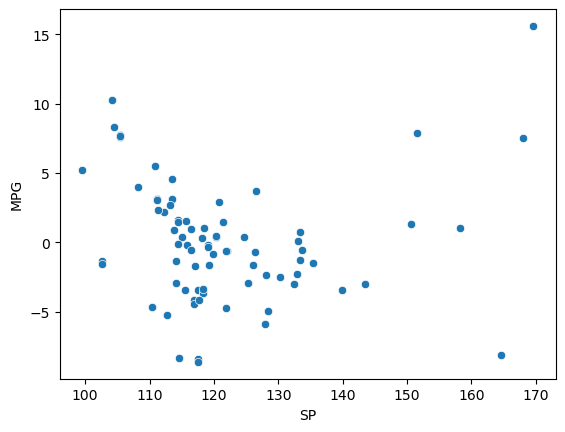

In [44]:
sns.scatterplot(data=cars_data,x="SP",y=Errors)

## Zero Residual Test

<Axes: xlabel='MPG', ylabel='MPG'>

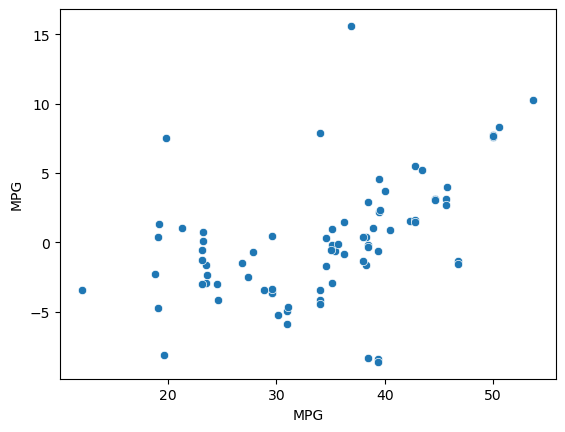

In [45]:
sns.scatterplot(x=cars_data["MPG"],y=Errors)

## Model Deployment

In [49]:
from pickle import dump
dump(obj=linear_model,file=open(file="linear_intelligence_file.pkl",mode='wb'))